In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
import numpy as np
import os
import scipy.io as sio

from google.colab import drive
drive.mount('/content/drive')

!tar -xvf "/content/drive/MyDrive/Penn_Action.tar.gz" -C "/content/"

Streaming output truncated to the last 5000 lines.
Penn_Action/frames/2282/000005.jpg
Penn_Action/frames/2282/000006.jpg
Penn_Action/frames/2282/000007.jpg
Penn_Action/frames/2282/000008.jpg
Penn_Action/frames/2282/000009.jpg
Penn_Action/frames/2282/000010.jpg
Penn_Action/frames/2282/000011.jpg
Penn_Action/frames/2282/000012.jpg
Penn_Action/frames/2282/000013.jpg
Penn_Action/frames/2282/000014.jpg
Penn_Action/frames/2282/000015.jpg
Penn_Action/frames/2282/000016.jpg
Penn_Action/frames/2282/000017.jpg
Penn_Action/frames/2282/000018.jpg
Penn_Action/frames/2282/000019.jpg
Penn_Action/frames/2282/000020.jpg
Penn_Action/frames/2282/000021.jpg
Penn_Action/frames/2282/000022.jpg
Penn_Action/frames/2282/000023.jpg
Penn_Action/frames/2282/000024.jpg
Penn_Action/frames/2282/000025.jpg
Penn_Action/frames/2282/000026.jpg
Penn_Action/frames/2282/000027.jpg
Penn_Action/frames/2282/000028.jpg
Penn_Action/frames/2282/000029.jpg
Penn_Action/frames/2282/000030.jpg
Penn_Action/frames/2282/000031.jpg
Penn

In [2]:
import scipy.io as sio
# Load the .mat file
mat_directory = '/content/Penn_Action/labels/'

mat_file = os.path.join(mat_directory, '0002.mat')
mat_contents = sio.loadmat(mat_file)

print(mat_contents['train'][0])
print(mat_contents['x'].shape)
print(mat_contents['y'].shape)
print(mat_contents['action'])


[1]
(80, 13)
(80, 13)
['baseball_pitch']


### Data Preprocessing


* Adjacency Matrix of each joint (13)
* Fix every x, y to a fixed Frame T (Padding/Cropping)
* Normalize Joint Coords



In [3]:

# defined based on analysis of the dataset
CLASS_NAMES = [
    'baseball_pitch', 'baseball_swing', 'bench_press', 'bowl',
    'clean_and_jerk', 'golf_swing', 'jump_rope', 'jumping_jacks',
    'pullup', 'pushup', 'situp', 'squat', 'strum_guitar',
    'tennis_forehand', 'tennis_serve'
]
CLASS_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

print(CLASS_MAP)

def raw_train_test_data():
  train_data = []
  train_labels = []
  test_data = []
  test_labels = []
  # Sort the file list to ensure deterministic order
  for matfile in sorted(os.listdir(mat_directory)):
      if matfile.endswith('.mat'):
          mat_file = os.path.join(mat_directory, matfile)
          mat_contents = sio.loadmat(mat_file)
          if (mat_contents['train'][0] == 1):
              x_coords = mat_contents['x']
              y_coords = mat_contents['y']

              pose = np.stack((x_coords, y_coords), axis=-1)
              train_data.append(pose)

              # Extract and flatten label
              action = mat_contents['action']
              if isinstance(action, np.ndarray):
                  action = action.flat[0]

              # Handle potential naming mismatch if necessary
              action = str(action)
              if action == 'strumming_guitar':
                  action = 'strum_guitar'

              if action in CLASS_MAP:
                  train_labels.append(CLASS_MAP[action])
              else:
                  raise ValueError(f"Unknown action: {action}")
          elif(mat_contents['train'][0] == -1):
            x_coords = mat_contents['x']
            y_coords = mat_contents['y']

            pose = np.stack((x_coords, y_coords), axis=-1)
            test_data.append(pose)

            # Extract and flatten label
            action = mat_contents['action']
            if isinstance(action, np.ndarray):
                action = action.flat[0]

            if action in CLASS_MAP:
                test_labels.append(CLASS_MAP[action])
            else:
                raise ValueError(f"Unknown action: {action}")



  # Use dtype=object to handle variable length sequences (ragged array)
  return np.array(train_data, dtype=object), np.array(train_labels, dtype=np.int64), np.array(test_data, dtype=object), np.array(test_labels, dtype=np.int64)

raw_train, raw_labels, raw_test, raw_test_labels = raw_train_test_data()
print(f"Shape of first loaded sample: {raw_train[0].shape}")
print(raw_train.shape)
print(raw_test.shape)
print(raw_test_labels.shape)
print(f"First label index: {raw_labels[0]} ({CLASS_NAMES[raw_labels[0]]})")
print(raw_train[0][1])

{'baseball_pitch': 0, 'baseball_swing': 1, 'bench_press': 2, 'bowl': 3, 'clean_and_jerk': 4, 'golf_swing': 5, 'jump_rope': 6, 'jumping_jacks': 7, 'pullup': 8, 'pushup': 9, 'situp': 10, 'squat': 11, 'strum_guitar': 12, 'tennis_forehand': 13, 'tennis_serve': 14}
Shape of first loaded sample: (80, 13, 2)
(1258,)
(1068,)
(1068,)
First label index: 0 (baseball_pitch)
[[ 46.66666667  52.        ]
 [ 23.33333333  79.33333333]
 [ 67.33333333  72.        ]
 [ 34.66666667 106.        ]
 [ 82.66666667 107.33333333]
 [ 64.66666667  78.66666667]
 [ 78.66666667  80.66666667]
 [ 33.33333333 142.        ]
 [ 66.         150.        ]
 [ 48.         202.66666667]
 [ 66.         201.33333333]
 [ 27.33333333 259.33333333]
 [ 68.66666667 247.33333333]]


### Frame Distribution



*   Study the Distribution shape of frames across all training samples
*   List mean, median and mode
*   List 80-95th Percentile.



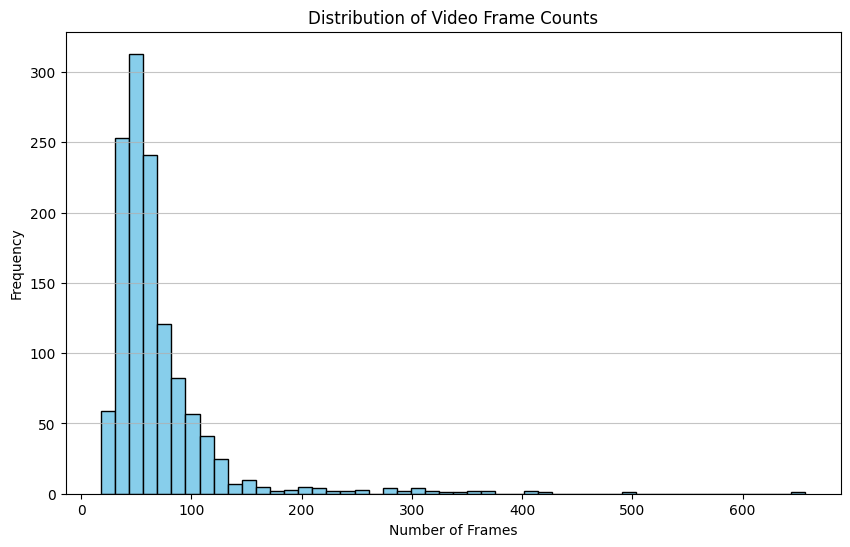

Minimum frames: 18
Maximum frames: 657
Mean frames: 69.59
Median frames: 57.0


In [4]:

# Extract frame counts from each sample
frame_counts = [sample.shape[0] for sample in raw_train]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(frame_counts, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Video Frame Counts')
plt.xlabel('Number of Frames')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Print statistics
print(f"Minimum frames: {np.min(frame_counts)}")
print(f"Maximum frames: {np.max(frame_counts)}")
print(f"Mean frames: {np.mean(frame_counts):.2f}")
print(f"Median frames: {np.median(frame_counts)}")

In [5]:
p80 = np.percentile(frame_counts, 80)
p90 = np.percentile(frame_counts, 90)
p95 = np.percentile(frame_counts, 95)

print(f"80th percentile: {p80}")
print(f"90th percentile: {p90}")
print(f"95th percentile: {p95}")

80th percentile: 85.0
90th percentile: 109.0
95th percentile: 137.59999999999945


Based on these calculations, picking **T = 100** is suitable as it will capture the full duration of nearly 90% of the actions while keeping the sequence length reasonable for training.

### Padding/Cropping
For each sample,

*   If T > 100, Crop
*   If T < 100, Pad
End Result: Tensor of shape $(1258, 100, 13, 2)$


In [6]:
def prepare_sequence(pose, target_frames=100):
    """
    Prepare sequence for ST-GCN using center crop and last-frame padding.

    Args:
        pose: (T_orig, V, M)  # Corrected docstring
        target_frames: desired temporal length (default 100)

    Returns:
        pose: (target_frames, V, M) # Corrected docstring
    """
    T_orig, V, M = pose.shape

    if T_orig == target_frames:
        return pose

    elif T_orig > target_frames:
        # Center crop
        start = (T_orig - target_frames) // 2
        return pose[start:start+target_frames, :, :] # Corrected slicing

    else:  # T_orig < target_frames
        # Pad by repeating last valid frame
        last_frame = pose[-1:, :, :]  # (1, V, M)  Corrected slicing
        num_pad = target_frames - T_orig
        padding = np.tile(last_frame, (num_pad, 1, 1)) # Corrected tiling
        return np.concatenate([pose, padding], axis=0) # Corrected axis for concatenate

train_data = []
for sample in raw_train:
  train_data.append(prepare_sequence(sample))

test_data = []
for sample in raw_test:
  test_data.append(prepare_sequence(sample))

# Convert list of arrays to a single numpy array
train_data = np.array(train_data)
test_data = np.array(test_data)

print(train_data.shape)

print(train_data[0][1])
print(raw_labels[0])


(1258, 100, 13, 2)
[[ 46.66666667  52.        ]
 [ 23.33333333  79.33333333]
 [ 67.33333333  72.        ]
 [ 34.66666667 106.        ]
 [ 82.66666667 107.33333333]
 [ 64.66666667  78.66666667]
 [ 78.66666667  80.66666667]
 [ 33.33333333 142.        ]
 [ 66.         150.        ]
 [ 48.         202.66666667]
 [ 66.         201.33333333]
 [ 27.33333333 259.33333333]
 [ 68.66666667 247.33333333]]
0


### Normalize Joints

We apply the following normalization strategy to make the data invariant to camera position and subject scale:

**Coordinate Centering:** For each frame, we calculate the Hip Center as the midpoint between the left and right hips (Joints 7 & 8). We then subtract this value from all joint coordinates, effectively setting the hip center as the origin $(0,0)$$(0,0)$.
* **Scale Normalization:** We calculate the Torso Length as the Euclidean distance between the Hip Center and the Shoulder Center (midpoint of Joints 1 & 2). All joint coordinates are then divided by this length.
Result:

The subject is centered in the frame.
The coordinates are unit-independent and relative to body size.

In [7]:
def normalize_data(data):
    """
    Normalize skeleton data.
    1. Center at hip midpoint.
    2. Scale by torso length (distance between hip midpoint and shoulder midpoint).

    Args:
        data: (N, T, V, C) array

    Returns:
        normalized_data: (N, T, V, C) array
    """
    N, T, V, C = data.shape
    data_norm = data.copy()

    # Joint Indices from previous cell context:
    # 1=l_shoulder, 2=r_shoulder
    # 7=l_hip, 8=r_hip

    for n in range(N):
        for t in range(T):
            skeleton = data[n, t] # (V, C)

            # Calculate Centers
            hip_center = (skeleton[7] + skeleton[8]) / 2.0
            shoulder_center = (skeleton[1] + skeleton[2]) / 2.0

            # Calculate Torso Length (Scale)
            # Add epsilon to avoid division by zero
            torso_len = np.linalg.norm(shoulder_center - hip_center) + 1e-6

            # Center and Scale
            data_norm[n, t] = (skeleton - hip_center) / torso_len

    return data_norm

# Apply normalization
train_data_norm = normalize_data(train_data)
test_data_norm = normalize_data(test_data)

print("Original shape:", train_data.shape)
print("Normalized shape:", train_data_norm.shape)
print("\nSample normalized frame (Joint 0 - Head):\n", train_data_norm[0, 0, 0])

Original shape: (1258, 100, 13, 2)
Normalized shape: (1258, 100, 13, 2)

Sample normalized frame (Joint 0 - Head):
 [-0.05351547 -1.35734685]


In [8]:
from pathlib import Path
import json

# After creating train_data, train_label, test_data, test_label

output_dir = Path('Penn_Action/processed/joint')
output_dir.mkdir(parents=True, exist_ok=True)

# Save numpy arrays
np.save(output_dir / 'train_data.npy', train_data)
np.save(output_dir / 'train_label.npy', raw_labels)
np.save(output_dir / 'test_data.npy', test_data)
np.save(output_dir / 'test_label.npy', raw_test_labels)


# Save metadata
metadata = {
    'dataset': 'Penn_Action',
    'num_classes': 15,
    'num_joints': 13,
    'num_coords': 2,
    'num_persons': 1,
    'max_frames': 100,
    'train_samples': int(len(raw_labels)),
    'test_samples': int(len(raw_test_labels)),
    'class_names': CLASS_NAMES, # Use the global list defined earlier
    'normalization': 'hip_centered_torso_scaled',
    'temporal_strategy': 'center_crop_or_last_frame_pad'
}

with open(output_dir.parent / 'meta.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Saved to {output_dir}")
print(f"  Train: {train_data.shape} -> {metadata['train_samples']} samples")
print(f"  Test:  {test_data.shape}  -> {metadata['test_samples']} samples")

✓ Saved to Penn_Action/processed/joint
  Train: (1258, 100, 13, 2) -> 1258 samples
  Test:  (1068, 100, 13, 2)  -> 1068 samples


In [9]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import numpy as np

# 1. Prepare Labels
# raw_labels is now (N,) containing ints.
y_train = torch.tensor(raw_labels, dtype=torch.long)
y_test = torch.tensor(raw_test_labels, dtype=torch.long)

# 2. Prepare Data
# Current shape: (N, T, V, C) -> (1258, 100, 13, 2)
# Desired shape: (N, C, T, V, M) -> (1258, 2, 100, 13, 1)

# Transpose to (N, C, T, V)
X_transposed = np.transpose(train_data_norm, (0, 3, 1, 2))
x_test_transposed = np.transpose(test_data_norm, (0, 3, 1, 2))

# Add Person dimension (M=1)
X_final = np.expand_dims(X_transposed, axis=-1)
x_test_final = np.expand_dims(x_test_transposed, axis=-1)

# Convert to Tensor
X_train = torch.tensor(X_final, dtype=torch.float32)
x_test = torch.tensor(x_test_final, dtype=torch.float32)

print(f"Final Train Data Tensor Shape: {X_train.shape}")

print(f"Final Train Label Tensor Shape: {y_train.shape}")

print(f"Final Test Data Tensor Shape: {x_test.shape}")

print(f"Final Test Label Tensor Shape: {y_test.shape}")

# 3. Create DataLoader
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Verify Batch Dimensions
params = {"batch_size": BATCH_SIZE, "shuffle": True}
train_data_batch, train_label_batch = next(iter(train_loader))
test_data_batch, test_label_batch = next(iter(test_loader))

print("\nDataLoader Created!")
print(f"Train Batch Data Shape: {train_data_batch.shape} -> (Batch, Channel, Frame, Joint, Person)")
print(f"Train Batch Label Shape: {train_label_batch.shape}")

print(f"Test Batch Data Shape: {test_data_batch.shape}")
print(f"Test Batch Label Shape: {test_label_batch.shape}")

Final Train Data Tensor Shape: torch.Size([1258, 2, 100, 13, 1])
Final Train Label Tensor Shape: torch.Size([1258])
Final Test Data Tensor Shape: torch.Size([1068, 2, 100, 13, 1])
Final Test Label Tensor Shape: torch.Size([1068])

DataLoader Created!
Train Batch Data Shape: torch.Size([32, 2, 100, 13, 1]) -> (Batch, Channel, Frame, Joint, Person)
Train Batch Label Shape: torch.Size([32])
Test Batch Data Shape: torch.Size([32, 2, 100, 13, 1])
Test Batch Label Shape: torch.Size([32])


### Improvement 1: Skeleton Data Augmentation
Baseline test accuracy: 76.69% (val: 83.33%)
Train/test gap: ~21.5% — primary motivation for augmentation as regularisation.

Five augmentations applied training-only:
1. Random rotation        (spatial)
2. Random scaling         (spatial)  
3. Random temporal crop   (temporal)
4. Speed perturbation     (temporal)

In [10]:
def seed_everything(seed=42):
    """Pin every source of randomness for full reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    """Ensure each DataLoader worker has a deterministic seed."""
    np.random.seed(torch.initial_seed() % 2**32)

seed_everything()

In [11]:
def augment_rotate(sequence: np.ndarray, angle_range: tuple = (5.0, 20.0)) -> np.ndarray:
    """
    Rotate all joints by a random angle to simulate viewpoint variation.

    The paper rotates 3D data around the y-axis (world up). For 2D Penn
    Action data (x, y only) this reduces to a standard 2D in-plane rotation:

        R(θ) = [[cos θ, -sin θ],
                [sin θ,  cos θ]]

        D_rotate = R · D                    (Eq. 8, adapted for 2D)

    Args:
        sequence    : (T, V, C=2) float32 array
        angle_range : (min_deg, max_deg) — paper specifies (5, 20)

    Returns:
        (T, V, C=2) float32 array
    """
    theta = np.radians(np.random.uniform(angle_range[0], angle_range[1]))

    cos_t, sin_t = np.cos(theta), np.sin(theta)
    R = np.array([[cos_t, -sin_t],
                  [sin_t,  cos_t]], dtype=np.float32)

    # (T, V, 2) @ (2, 2) -> (T, V, 2)  — applies R to every joint in every frame
    return (sequence @ R.T).astype(np.float32)


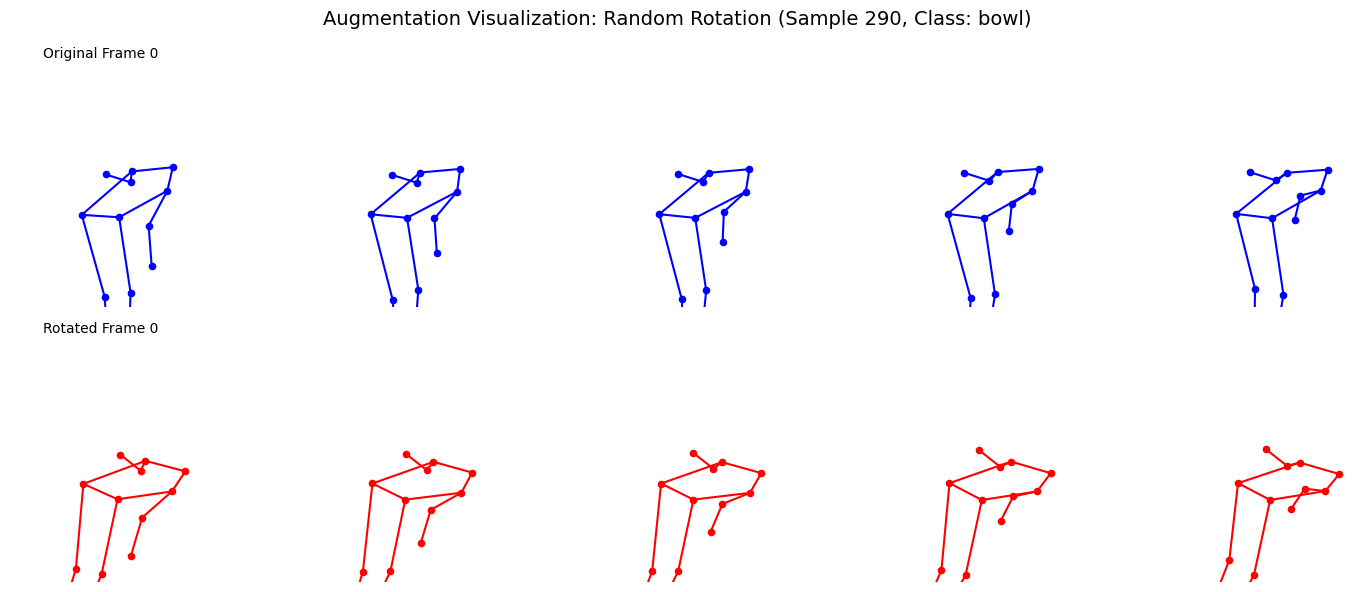

In [12]:
import matplotlib.pyplot as plt

# Define edges for plotting (matches Penn Action topology)
edges = [
    (0, 1), (0, 2),
    (1, 7), (2, 8), (7, 8),
    (1, 3), (3, 5),
    (2, 4), (4, 6),
    (7, 9), (9, 11),
    (8, 10), (10, 12),
]

def plot_skeleton(ax, points, color, title=None):
    """Helper to plot a single skeleton frame."""
    # Plot joints
    ax.scatter(points[:, 0], points[:, 1], c=color, s=20)

    # Plot connections
    for i, j in edges:
        ax.plot([points[i, 0], points[j, 0]],
                [points[i, 1], points[j, 1]], color=color)

    if title:
        ax.set_title(title, fontsize=10)

    # Keep axis consistent (normalized coordinates are roughly -2 to 2)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-2.5, 1.5)
    ax.invert_yaxis()  # Image coords usually have Y pointing down
    ax.set_aspect('equal')
    ax.axis('off')

# 1. Pick a sample
sample_idx = 290
original_seq = train_data_norm[sample_idx]  # Shape (100, 13, 2)

# 2. Apply augmentation (Run previous cell to define augment_rotate first!)
try:
    rotated_seq = augment_rotate(original_seq, angle_range=(15.0, 30.0)) # Force visible rotation
except NameError:
    print("Error: augment_rotate is not defined. Please run the cell defining it first.")
    # Fallback to identity for demo if function missing
    rotated_seq = original_seq

# 3. Plot
frames_to_plot = 5
fig, axs = plt.subplots(2, frames_to_plot, figsize=(15, 6))

for t in range(frames_to_plot):
    # Original
    plot_skeleton(axs[0, t], original_seq[t], 'blue',
                  title=f"Original Frame {t}" if t==0 else None)

    # Rotated
    plot_skeleton(axs[1, t], rotated_seq[t], 'red',
                  title=f"Rotated Frame {t}" if t==0 else None)

plt.suptitle(f"Augmentation Visualization: Random Rotation (Sample {sample_idx}, Class: {CLASS_NAMES[raw_labels[sample_idx]]})", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
def augment_gaussian_noise(sequence: np.ndarray, sigma: float = 0.01) -> np.ndarray:
    """
    Add independent Gaussian noise to every joint coordinate in every frame.

    Paper formula:
        D_noise = D + N,  N ~ N(0, σ²)              (Section 3.3.1)

    σ = 0.01 is the value used in the paper.

    Args:
        sequence : (T, V, C=2) float32 array
        sigma    : standard deviation of the noise distribution (paper: 0.01)

    Returns:
        (T, V, C=2) float32 array
    """
    noise = np.random.normal(loc=0.0, scale=sigma, size=sequence.shape).astype(np.float32)
    return (sequence + noise).astype(np.float32)

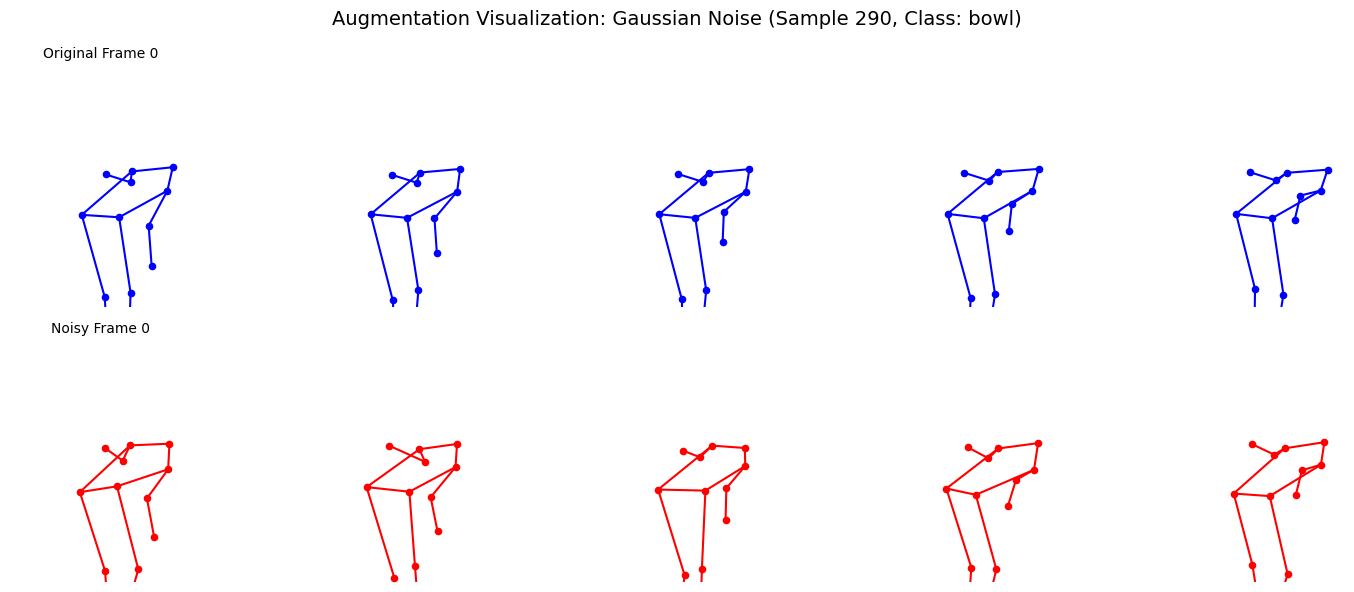

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `edges` and `plot_skeleton` are already defined and available from previous cells.
# If not, you might need to re-execute the cell that defines them.

# 1. Pick a sample
sample_idx = 290 # Using the same sample index as the rotation visualization
original_seq = train_data_norm[sample_idx]  # Shape (100, 13, 2)

# 2. Apply augmentation
# Use a slightly higher sigma to make the noise more visually apparent for demonstration
noisy_seq = augment_gaussian_noise(original_seq, sigma=0.05)

# 3. Plot
frames_to_plot = 5
fig, axs = plt.subplots(2, frames_to_plot, figsize=(15, 6))

for t in range(frames_to_plot):
    # Original
    plot_skeleton(axs[0, t], original_seq[t], 'blue',
                  title=f"Original Frame {t}" if t==0 else None)

    # Noisy
    plot_skeleton(axs[1, t], noisy_seq[t], 'red',
                  title=f"Noisy Frame {t}" if t==0 else None)

plt.suptitle(f"Augmentation Visualization: Gaussian Noise (Sample {sample_idx}, Class: {CLASS_NAMES[raw_labels[sample_idx]]})", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
# TEMPORAL AUGMENTATION 1 — Time Interpolation  (Section 3.3.2, Equation 14)
# =============================================================================

def augment_time_interpolation(sequence: np.ndarray, gamma: int = 2) -> np.ndarray:
    """
    Args:
        sequence : (T, V, C=2) float32 array
        gamma    : interpolation factor, integer ≥ 2  (paper Figure 3 uses γ=2)

    Returns:
        (T, V, C=2) float32 array — T frames uniformly sampled from the full
        densified sequence of length T*gamma
    """
    T     = sequence.shape[0]
    V     = sequence.shape[1]
    C     = sequence.shape[2]
    T_out = T * gamma

    output = np.empty((T_out, V, C), dtype=np.float32)

    # ── Region 1: preserve original frames at positions 0 .. T-1
    output[:T] = sequence

    # ── Region 2: insert interpolated frames at positions T .. T*gamma-1
    for t in range(T, T_out):
        source_lo = int(np.floor(t / gamma))
        source_hi = min(source_lo + 1, T - 1)         # clip to avoid out-of-bounds

        # Fractional weight from Eq. 14: (γ·t mod γ) normalised to [0, 1)
        weight = float((gamma * t) % gamma) / gamma

        output[t] = (sequence[source_lo]
                     + weight * (sequence[source_hi] - sequence[source_lo]))

    # Uniformly stride-sample T frames across the full densified sequence.
    # This covers the complete action (frame 0 through T*gamma-1) rather than
    # cropping to Region 2, eliminating the train/test distribution mismatch.
    indices = np.linspace(0, T_out - 1, T, dtype=int)
    return output[indices]   # shape (T, V, C)

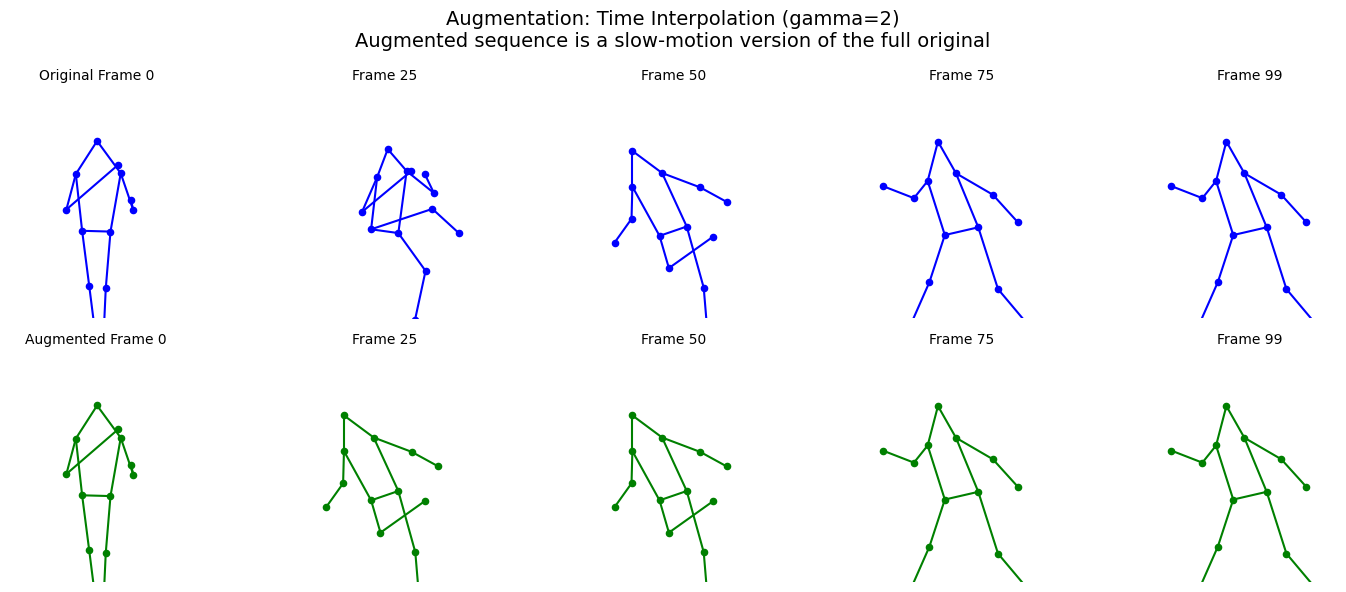

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse the plotting function and edges from previous cells
# (Assuming `edges` and `plot_skeleton` are defined. If not, re-run the rotation viz cell)

# 1. Pick a sample
# Ideally, pick an action with distinct movement in the second half
sample_idx = 81  # Baseball pitch often has the release/follow-through in the second half
original_seq = train_data_norm[sample_idx]

# 2. Apply augmentation
interpolated_seq = augment_time_interpolation(original_seq, gamma=2)

# 3. Visualize
# With gamma=2, the augmented sequence is effectively the 2nd half of the original,
# stretched to be twice as long.
# So Augmented Frame 0 corresponds roughly to Original Frame 50 (if T=100).

T = original_seq.shape[0]
frames_to_show = [0, 25, 50, 75, 99] # Indices to sample from both tensors

fig, axs = plt.subplots(2, len(frames_to_show), figsize=(15, 6))

for i, t_idx in enumerate(frames_to_show):
    # Original Row
    plot_skeleton(axs[0, i], original_seq[t_idx], 'blue',
                  title=f"Original Frame {t_idx}" if i==0 else f"Frame {t_idx}")

    # Augmented Row
    # Note: Augmented Frame 0 starts from the middle of the original action
    plot_skeleton(axs[1, i], interpolated_seq[t_idx], 'green',
                  title=f"Augmented Frame {t_idx}" if i==0 else f"Frame {t_idx}")

plt.suptitle(f"Augmentation: Time Interpolation (gamma=2)\nAugmented sequence is a slow-motion version of the full original", fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# TEMPORAL AUGMENTATION 2 — Time Warping  (Section 3.3.2, Equation 16)
# =============================================================================

def augment_time_warp(
    sequence: np.ndarray,
    num_segments: int = 5,
    t_std: float      = 1.5,
) -> np.ndarray:
    """
    Apply piecewise random time-scaling across independent segments.

    The paper defines the warp per frame as (Eq. 16):

        D_warping(j', k, c) = D(floor(j + t), k, c)

    Where:
        j  = original frame index within the current segment
        t  = random real-valued scaling factor, drawn fresh per segment
        j' = output frame index (0 … T-1, sequential by construction)

    A new t is drawn from Normal(0, t_std) for each segment and clipped to
    ±segment_length/2 to prevent degenerate lookups. floor() performs an
    integer frame lookup with no interpolation, exactly as in Eq. 16.
    Concatenating all segments restores the original length T.

    Args:
        sequence     : (T, V, C=2) float32 array
        num_segments : number of independently warped segments (default 5)
        t_std        : std of the Gaussian used to draw t per segment

    Returns:
        (T, V, C=2) float32 array — same length as input, locally warped
    """
    T              = sequence.shape[0]
    segment_length = T // num_segments
    warped_frames  = []

    for seg_idx in range(num_segments):
        seg_start = seg_idx * segment_length

        # Last segment absorbs any remainder from integer division
        seg_end = T if seg_idx == num_segments - 1 else seg_start + segment_length

        # Draw an independent time-scaling offset for this segment (Eq. 16)
        half_len = segment_length / 2.0
        t = float(np.clip(np.random.normal(0.0, t_std), -half_len, half_len))

        for j in range(seg_start, seg_end):
            source_index = int(np.clip(int(np.floor(j + t)), 0, T - 1))  # Eq. 16
            warped_frames.append(sequence[source_index])

    # Stack all segments — total length equals T by construction
    return np.stack(warped_frames, axis=0).astype(np.float32)  # (T, V, C)


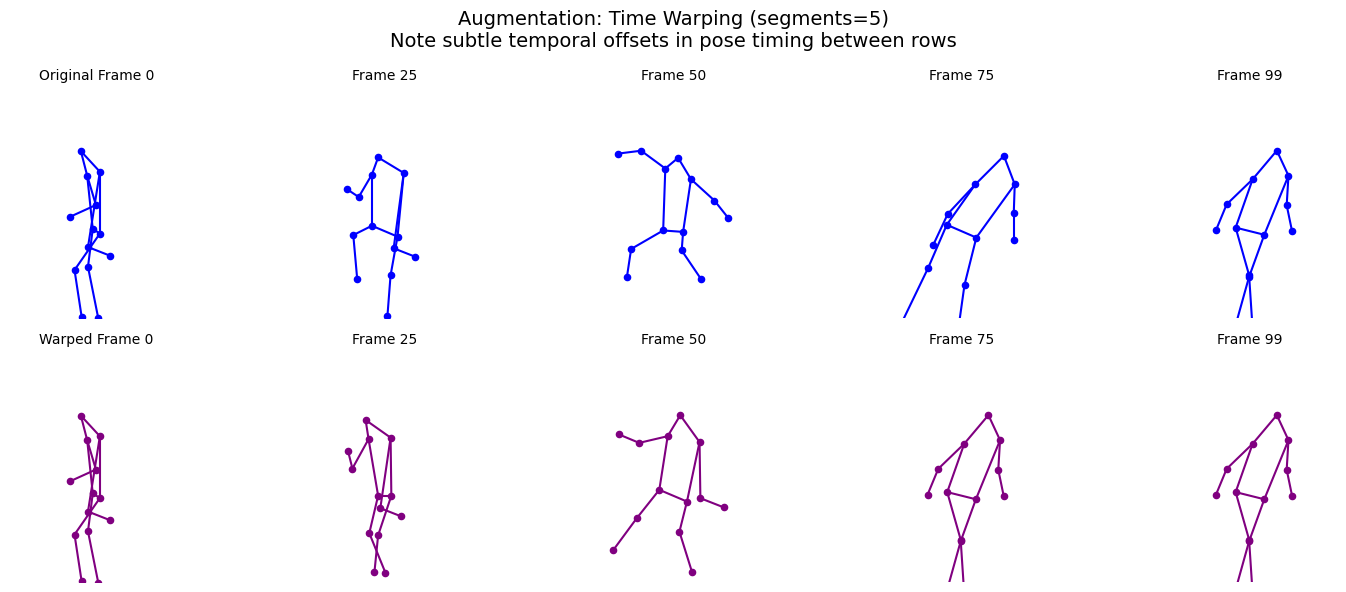

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse the plotting function and edges from previous cells

# 1. Pick a sample
sample_idx = 4
original_seq = train_data_norm[sample_idx]

# 2. Apply augmentation
# Increase t_std slightly to make the effect more visible for the plot
warped_seq = augment_time_warp(original_seq, num_segments=5, t_std=8.0)

# 3. Visualize
frames_to_show = [0, 25, 50, 75, 99]

fig, axs = plt.subplots(2, len(frames_to_show), figsize=(15, 6))

for i, t_idx in enumerate(frames_to_show):
    # Original Row
    plot_skeleton(axs[0, i], original_seq[t_idx], 'blue',
                  title=f"Original Frame {t_idx}" if i==0 else f"Frame {t_idx}")

    # Warped Row
    plot_skeleton(axs[1, i], warped_seq[t_idx], 'purple',
                  title=f"Warped Frame {t_idx}" if i==0 else f"Frame {t_idx}")

plt.suptitle(f"Augmentation: Time Warping (segments=5)\nNote subtle temporal offsets in pose timing between rows", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# COMPOSED AUGMENTATION PIPELINE
# =============================================================================

def apply_augmentations(
    sequence: np.ndarray,
    training: bool  = True,
    p_rotate: float = 0.5,
    p_noise:  float = 0.5,
    p_interp: float = 0.5,
    p_warp:   float = 0.5,
) -> np.ndarray:
    """
    Apply the augmentation pipeline to one skeleton sequence, with each
    augmentation applied independently at its own probability.

    Each augmentation is applied independently: e.g. with p=0.5, ~6% of
    samples receive all four augmentations, ~25% receive none, and the rest
    receive a random subset — matching how real variation occurs in practice.

    Val and test sequences are always returned unchanged (training=False).

    Args:
        sequence  : (T=100, V=13, C=2) float32 array
        training  : if False, returns the sequence unmodified (strict no-op)
        p_rotate  : probability of applying random rotation      (default 0.5)
        p_noise   : probability of applying Gaussian noise        (default 0.5)
        p_interp  : probability of applying time interpolation    (default 0.5)
        p_warp    : probability of applying time warping          (default 0.5)

    Returns:
        (T=100, V=13, C=2) float32 array
    """
    if not training:
        return sequence

    if np.random.random() < p_rotate:
        sequence = augment_rotate(sequence)
    if np.random.random() < p_noise:
        sequence = augment_gaussian_noise(sequence)
    if np.random.random() < p_interp:
        sequence = augment_time_interpolation(sequence)
    if np.random.random() < p_warp:
        sequence = augment_time_warp(sequence)

    return sequence

# =============================================================================
# DATASET INTEGRATION
# =============================================================================

class PennActionDatasetAug(Dataset):
    """
    Penn Action dataset with optional skeleton augmentation.

    Augmentation is applied per-sample inside __getitem__, so each epoch
    sees a freshly randomised version of every training sequence.

    Usage:
        train_ds = PennActionDatasetAug(train_data, train_labels, training=True)
        val_ds   = PennActionDatasetAug(val_data,   val_labels,   training=False)
        test_ds  = PennActionDatasetAug(test_data,  test_labels,  training=False)
    """

    def __init__(self, data_path: str, label_path: str, training: bool = True):
        """
        Args:
            data_path  : path to .npy file of shape (N, T, V, C)
            label_path : path to .npy file of shape (N,)
            training   : True activates augmentation; False is a strict no-op
        """
        # mmap_mode='r' avoids loading the full array into RAM
        self.data     = np.load(data_path,  mmap_mode='r')
        self.labels   = np.load(label_path).astype(np.int64)
        self.training = training

    def __len__(self) -> int:
        return len(self.labels)

    @property
    def num_classes(self) -> int:
        return int(self.labels.max()) + 1

    def __getitem__(self, idx: int):
        # .copy() required — mmap_mode='r' makes the array read-only
        x = self.data[idx].copy()                  # (T, V, C)

        x = apply_augmentations(x, self.training)  # (T, V, C)

        # Reshape to ST-GCN input format: (C, T, V, M)
        x = np.transpose(x, (2, 0, 1))             # (C, T, V)
        x = np.expand_dims(x, axis=-1)             # (C, T, V, M=1)

        return (
            torch.tensor(x,                dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

### Improvement 3: Four-Stream Input Fusion (MS-AAGCN)

Four modalities are derived from the raw joint coordinates and fed to four **independently trained** ST-GCN models with identical hyperparameters:

1. **Joint** — raw $(x, y)$ coordinates. Encodes absolute pose.
2. **Bone** — directed difference $\text{bone}_j = \text{joint}_j - \text{joint}_{\text{parent}(j)}$ along the 12 skeleton edges (Appendix C.1). Root joint's bone is zero. Encodes limb orientation and length.
3. **Joint-motion** — frame-wise velocity $\Delta\text{joint}_t = \text{joint}_{t+1} - \text{joint}_t$, zero-padded at $t{=}T{-}1$.
4. **Bone-motion** — frame-wise velocity of the bone tensor. Encodes limb acceleration.

At inference, the four softmax outputs are combined with weights $(2{:}1{:}2{:}1)$ normalised to sum to 1, following MS-AAGCN convention — joint and joint-motion carry double weight since they are the dominant streams in prior work.

Augmentation is applied to the raw joints **before** streams are derived, so bones and motion stay geometrically consistent with the augmented skeleton.


In [20]:
# =============================================================================
# FOUR-STREAM INPUT DERIVATION  (MS-AAGCN)
# =============================================================================

# Bone parent mapping
# For each of the 13 joints, PENN_BONE_PARENT[j] is the index of joint j's
# parent in a spanning tree rooted at joint 7 (l_hip). The root has
# PARENT[7] = 7, so its bone vector is zero — this preserves the V=13 shape
# All 12 parent-links correspond to actual skeleton edges
# The one skeleton edge not used as a parent-link is (0,2) — the cycle-breaker
# for the 0-1-7-8-2-0 cycle. That edge remains in the adjacency matrix A for
# spatial graph convolution; only the bone-derivation step excludes it.
PENN_BONE_PARENT = np.array([
    1,   # 0  head        <- 1  l_shoulder     (edge 0-1)
    7,   # 1  l_shoulder  <- 7  l_hip          (edge 1-7, spine)
    8,   # 2  r_shoulder  <- 8  r_hip          (edge 2-8, spine)
    1,   # 3  l_elbow     <- 1  l_shoulder     (edge 1-3)
    2,   # 4  r_elbow     <- 2  r_shoulder     (edge 2-4)
    3,   # 5  l_wrist     <- 3  l_elbow        (edge 3-5)
    4,   # 6  r_wrist     <- 4  r_elbow        (edge 4-6)
    7,   # 7  l_hip       <- self (root, zero bone)
    7,   # 8  r_hip       <- 7  l_hip          (edge 7-8, hip bridge)
    7,   # 9  l_knee      <- 7  l_hip          (edge 7-9)
    8,   # 10 r_knee      <- 8  r_hip          (edge 8-10)
    9,   # 11 l_ankle     <- 9  l_knee         (edge 9-11)
    10,  # 12 r_ankle     <- 10 r_knee         (edge 10-12)
], dtype=np.int64)


def compute_bone_stream(joints: np.ndarray) -> np.ndarray:
    """
    Derive the bone stream from raw joint coordinates.

    bone[t, j, :] = joint[t, j, :] - joint[t, parent[j], :]

    Args:
        joints: (T, V, C) array of joint coordinates

    Returns:
        bones:  (T, V, C) array of bone vectors
    """
    return joints - joints[:, PENN_BONE_PARENT, :]


def compute_motion_stream(sequence: np.ndarray) -> np.ndarray:
    """
    Derive the motion (velocity) stream from a joint or bone sequence.

    motion[t, j, :] = sequence[t+1, j, :] - sequence[t, j, :]  for t < T-1
    motion[T-1, :, :] = 0                                       (zero-padded)

    The zero-pad at the final frame preserves T so all four streams have
    identical shape.

    Args:
        sequence: (T, V, C) array (joint coordinates or bone vectors)

    Returns:
        motion:   (T, V, C) array of frame differences
    """
    motion = np.zeros_like(sequence)
    motion[:-1] = sequence[1:] - sequence[:-1]
    return motion


def derive_stream(joints: np.ndarray, stream: str) -> np.ndarray:
    """
    Given raw joint coordinates, return the requested MS-AAGCN stream.

    Args:
        joints : (T, V, C) raw joint coordinates (post-augmentation)
        stream : one of {'joint', 'bone', 'joint_motion', 'bone_motion'}

    Returns:
        (T, V, C) tensor in the requested modality
    """
    if stream == 'joint':
        return joints
    if stream == 'bone':
        return compute_bone_stream(joints)
    if stream == 'joint_motion':
        return compute_motion_stream(joints)
    if stream == 'bone_motion':
        return compute_motion_stream(compute_bone_stream(joints))
    raise ValueError(
        f"Unknown stream '{stream}'. "
        f"Expected one of: joint, bone, joint_motion, bone_motion."
    )


# =============================================================================
# DATASET WRAPPER WITH STREAM SELECTION
# =============================================================================

class PennActionStreamDataset(Dataset):
    """
    Penn Action dataset emitting one of the four MS-AAGCN input streams.

    Per-sample pipeline in __getitem__:
        1. Load raw joints (T, V, C) from the mmap'd .npy file.
        2. If training=True, apply the augmentation pipeline to raw joints.
        3. Derive the requested stream from the (augmented) joints.
        4. Reshape to ST-GCN input format: (C, T, V, M=1).

    Usage:
        train_ds = PennActionStreamDataset(TRAIN_PATH, LABEL_PATH,
                                           stream='bone', training=True)
        val_ds   = PennActionStreamDataset(TRAIN_PATH, LABEL_PATH,
                                           stream='bone', training=False)
    """

    VALID_STREAMS = ('joint', 'bone', 'joint_motion', 'bone_motion')

    def __init__(self, data_path: str, label_path: str,
                 stream: str = 'joint', training: bool = True):
        """
        Args:
            data_path  : path to .npy of shape (N, T, V, C) raw joints
            label_path : path to .npy of shape (N,)
            stream     : which MS-AAGCN modality to emit
            training   : True activates augmentation (applied to raw joints
                         before stream derivation); False is a strict no-op
        """
        if stream not in self.VALID_STREAMS:
            raise ValueError(
                f"stream must be one of {self.VALID_STREAMS}, got '{stream}'"
            )
        self.data     = np.load(data_path, mmap_mode='r')
        self.labels   = np.load(label_path).astype(np.int64)
        self.stream   = stream
        self.training = training

    def __len__(self) -> int:
        return len(self.labels)

    @property
    def num_classes(self) -> int:
        return int(self.labels.max()) + 1

    def __getitem__(self, idx: int):
        # Step 1: load raw joints
        x = self.data[idx].copy()                  # (T, V, C)

        # Step 2: augment raw joints first (no-op when training=False)
        x = apply_augmentations(x, self.training)  # (T, V, C)

        # Step 3: derive the requested stream from the augmented joints
        x = derive_stream(x, self.stream)          # (T, V, C)

        # Step 4: reshape to ST-GCN input (C, T, V, M=1)
        x = np.transpose(x, (2, 0, 1))             # (C, T, V)
        x = np.expand_dims(x, axis=-1)             # (C, T, V, M=1)

        return (
            torch.tensor(x,                dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


In [21]:
# SINGLE-STREAM TRAINING + FOUR-STREAM FUSION EVALUATION
# Implements Improvement 3
#
# Workflow:
#   1. Train four independent ST-GCN models, one per stream, with identical
#      hyperparameters and the same train/val split (stratified).
#   2. At test time, each model produces softmax probabilities on the test
#      set. The four probability tensors are weighted-averaged with (2:1:2:1)
#      normalised weights, giving the fused prediction.

STREAMS = ['joint', 'bone', 'joint_motion', 'bone_motion']

# MS-AAGCN (Shi et al. IEEE TIP 2020) weights: (2:1:2:1)
FUSION_WEIGHTS = {
    'joint':        2.0,
    'bone':         1.0,
    'joint_motion': 2.0,
    'bone_motion':  1.0,
}

STREAM_CKPT_PATTERN = 'best_model_{stream}.pth'


def train_single_stream(stream: str, cfg: dict, device: torch.device,
                        verbose: bool = True):
    """
    Train one ST-GCN model on a single input stream. Mirrors run_train_eval()
    structure (same training loop, early stopping, W&B logging) but configures
    the dataset to emit the requested stream and saves to a stream-specific
    checkpoint path.

    Args:
        stream : one of STREAMS
        cfg    : config dict (BEST_CONFIG-shaped)
        device : torch device
        verbose: print per-epoch updates

    Returns:
        (best_val_acc, test_acc_single, ckpt_path)
    """
    ckpt_path = STREAM_CKPT_PATTERN.format(stream=stream)

    # Data: three dataset instances, all on the same stream
    # train_ds has training=True (augmentation active); val_ds and test_ds
    # have training=False (clean sequences). Augmentation runs on raw joints,
    # then the stream is derived — keeping bone/motion geometrically valid.
    train_ds = PennActionStreamDataset(TRAIN_DATA_PATH, TRAIN_LABEL_PATH,
                                       stream=stream, training=True)
    val_ds   = PennActionStreamDataset(TRAIN_DATA_PATH, TRAIN_LABEL_PATH,
                                       stream=stream, training=False)
    test_ds  = PennActionStreamDataset(TEST_DATA_PATH,  TEST_LABEL_PATH,
                                       stream=stream, training=False)
    num_classes = train_ds.num_classes

    # Same stratified split across all streams (same seed in cfg) so the
    # four models train on identical train/val indices — isolating stream
    # identity as the only source of variation between them.
    t_idx, v_idx = stratified_split(train_ds, cfg["val_ratio"], cfg["seed"])
    train_loader, val_loader = make_loaders(t_idx, v_idx, train_ds, val_ds,
                                            cfg["batch_size"])
    test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"],
                             shuffle=False, num_workers=2, pin_memory=True)

    # Model
    model, opt, sched = build_model_and_optimiser(cfg, num_classes, device)
    criterion = nn.CrossEntropyLoss()
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f"\n  Stream: {stream}  |  params: {num_params:,}  "
              f"|  adaptive: {cfg.get('adaptive', True)}")

    # W&B run (one per stream, grouped for easy comparison)
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f"fusion-{stream}",
        group   = "four-stream-fusion",
        config  = {**cfg, "stream": stream, "num_params": num_params,
                   "mode": "single_stream"},
        reinit  = True,
    )

    # Training loop (identical to run_train_eval's)
    best_val_acc  = 0.0
    best_epoch    = 0
    early_stopper = EarlyStopping(patience  = cfg["es_patience"],
                                  min_delta = cfg["es_min_delta"])

    for epoch in range(1, cfg["num_epochs"] + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, device, opt)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, device)
        sched.step()

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_epoch   = epoch
            torch.save(model.state_dict(), ckpt_path)

        wandb.log({
            "epoch":        epoch,
            "train_loss":   tr_loss, "train_acc": tr_acc,
            "val_loss":     vl_loss, "val_acc":   vl_acc,
            "best_val_acc": best_val_acc,
            "lr":           opt.param_groups[0]["lr"],
        })

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"    ep {epoch:3d}  "
                  f"tr {tr_loss:.3f}/{tr_acc:.1f}%  "
                  f"val {vl_loss:.3f}/{vl_acc:.1f}%  "
                  f"(best {best_val_acc:.1f}% @ {best_epoch})")

        if early_stopper(vl_loss):
            if verbose:
                print(f"    early stop @ epoch {epoch}")
            break

    # Single-stream test evaluation
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            preds = model(x.to(device)).argmax(1).cpu()
            correct += (preds == y).sum().item()
            total   += y.size(0)
    test_acc_single = 100.0 * correct / total

    wandb.summary["best_val_acc"]         = best_val_acc
    wandb.summary["test_accuracy_single"] = test_acc_single
    run.finish()

    if verbose:
        print(f"  ✓ {stream}: best_val={best_val_acc:.2f}%  "
              f"test_single={test_acc_single:.2f}%  -> {ckpt_path}")

    return best_val_acc, test_acc_single, ckpt_path


def _collect_stream_softmax(stream: str, cfg: dict, device: torch.device,
                            num_classes: int):
    """
    Load a trained stream's checkpoint and return its softmax predictions
    on the held-out test set, alongside the corresponding labels.

    The test DataLoader uses shuffle=False, so label order is deterministic
    and matches across all four streams — enabling element-wise fusion.

    Returns:
        probs  : (N_test, num_classes) numpy array of class probabilities
        labels : (N_test,) numpy array of ground-truth labels
    """
    ckpt_path = STREAM_CKPT_PATTERN.format(stream=stream)
    test_ds = PennActionStreamDataset(TEST_DATA_PATH, TEST_LABEL_PATH,
                                      stream=stream, training=False)
    test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"],
                             shuffle=False, num_workers=2, pin_memory=True)

    model, _, _ = build_model_and_optimiser(cfg, num_classes, device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    probs_chunks, labels_chunks = [], []
    with torch.no_grad():
        for x, y in test_loader:
            logits = model(x.to(device))
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            probs_chunks.append(probs)
            labels_chunks.append(y.numpy())
    return np.concatenate(probs_chunks, axis=0), np.concatenate(labels_chunks)


def run_four_stream_fusion():
    """
    End-to-end runner for Improvement 3.

    Stages:
        1. Train one ST-GCN per stream (saves 4 checkpoints on disk).
        2. Reload each checkpoint and collect softmax predictions on the
           held-out test set.
        3. Weighted-average the four probability tensors with (2:1:2:1)
           normalised to sum to 1.
        4. Report fused test accuracy + classification report, save the
           fused confusion matrix as confusion_matrix_fusion.png.

    Returns:
        results: dict with per-stream test accuracies, fused test accuracy,
                 fused confusion matrix, labels, and fused probabilities.
                 This is the data needed to populate Table 1 row (4) and
                 Figure 6 in the dissertation.
    """
    cfg = BEST_CONFIG.copy()

    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"\n{'='*62}")
    print(f"  FOUR-STREAM FUSION  —  {cfg['num_epochs']} epochs/stream")
    print(f"  Device: {device}  |  Adaptive: {cfg.get('adaptive', True)}")
    print(f"  Streams: {STREAMS}")
    print(f"  Fusion weights (unnormalised): {FUSION_WEIGHTS}")
    print(f"{'='*62}")

    # Stage 1: train each stream independently
    per_stream_results = {}
    for stream in STREAMS:
        # Re-seed before each stream so training is reproducible and any
        # differences between streams come from the data, not residual RNG
        # state from the previous stream's training run.
        seed_everything(cfg["seed"])
        best_val, test_single, ckpt = train_single_stream(stream, cfg, device)
        per_stream_results[stream] = {
            "best_val_acc":    best_val,
            "test_acc_single": test_single,
            "ckpt":            ckpt,
        }

    # Stage 2: collect softmax predictions from each trained model
    # Peek at num_classes once from the training dataset metadata.
    num_classes = PennActionStreamDataset(
        TRAIN_DATA_PATH, TRAIN_LABEL_PATH, stream='joint', training=False
    ).num_classes

    print(f"\n  Collecting softmax outputs from all four streams...")
    stream_probs = {}
    labels = None
    for stream in STREAMS:
        probs, lbls = _collect_stream_softmax(stream, cfg, device, num_classes)
        stream_probs[stream] = probs
        # Defensive check: the test loader uses shuffle=False across all
        # streams, so labels must be byte-identical. A mismatch would mean
        # silent desync and totally invalid fusion.
        if labels is None:
            labels = lbls
        else:
            assert np.array_equal(labels, lbls), \
                f"Label order mismatch on stream {stream} — fusion is invalid"

    # Stage 3: weighted score-level fusion
    # Normalise weights to sum to 1 so the fused output remains a valid
    # probability distribution.
    w_total = sum(FUSION_WEIGHTS[s] for s in STREAMS)
    fused_probs = sum(
        (FUSION_WEIGHTS[s] / w_total) * stream_probs[s] for s in STREAMS
    )   # (N_test, num_classes)

    fused_preds = fused_probs.argmax(axis=1)
    fusion_test_acc = accuracy_score(labels, fused_preds) * 100.0
    fusion_cm       = confusion_matrix(labels, fused_preds)

    # Stage 4: report + log
    print(f"\n{'─'*62}")
    print(f"  FOUR-STREAM FUSION — Test Set Results")
    print(f"{'─'*62}")
    for s in STREAMS:
        r = per_stream_results[s]
        print(f"    {s:14s}  test={r['test_acc_single']:6.2f}%   "
              f"val={r['best_val_acc']:6.2f}%   (weight={FUSION_WEIGHTS[s]})")
    print(f"    {'─'*54}")
    print(f"    {'FUSED (2:1:2:1)':14s}  test={fusion_test_acc:6.2f}%")
    print(f"{'─'*62}")

    report = classification_report(labels, fused_preds,
                                   target_names=CLASS_NAMES, digits=3)
    print("\n" + report)

    # Log fusion summary as a standalone W&B run for dashboard visibility.
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = "four-stream-fusion-summary",
        group   = "four-stream-fusion",
        config  = {**cfg, "mode": "fusion_eval",
                   "fusion_weights": FUSION_WEIGHTS,
                   "streams": STREAMS},
        reinit  = True,
    )
    for s in STREAMS:
        wandb.summary[f"test_acc_{s}"] = per_stream_results[s]["test_acc_single"]
    wandb.summary["test_acc_fused"] = fusion_test_acc

    # Fused confusion matrix
    fig, ax = plt.subplots(figsize=(13, 11))
    cm_norm = fusion_cm.astype(float) / fusion_cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.4, linecolor="lightgrey", ax=ax,
    )
    ax.set_title(f"Confusion Matrix — Four-Stream Fusion  "
                 f"(acc: {fusion_test_acc:.2f}%)", fontsize=14)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_xlabel("Predicted Label", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    cm_path = "confusion_matrix_fusion.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    wandb.log({"confusion_matrix_fusion": wandb.Image(cm_path)})

    run.finish()

    return {
        "per_stream":      per_stream_results,
        "fusion_test_acc": fusion_test_acc,
        "fusion_cm":       fusion_cm,
        "labels":          labels,
        "fused_probs":     fused_probs,
    }


## ST-GCN Lightweight Model



1.   Define Adjacency Matrix and Degree Normalization
2.   Define Dataset Wrapper.
* Turns ```train_data.npy, train_label.npy``` into Tensors of shape $(N, C, T, V, M)$.
3. Stratified Split of Training set for a validation set used for Hyperparam tuning.
4. Define ST-GCN Block:
* Spatial Convolution -> Batch Norm -> ReLU
* Temporal Convolution -> Batch Norm -> Dropout
* Residual Add (Skip or 1x1 Conv to match dimensions).
5. Define Lightweight ST-GCN Model:
* 6-Block ST-GCN $(32, 32, 64, 64, 128, 128 -> 14)$
* Temporal Blocks 3 and 5 halves frames with stride = 2. $(100, 50, 25)$
* Global Avg Pool -> Batch Norm -> Dropout -> FC(128)




### Spatial Convolution

In this baseline ST-GCN, I initially tested with a Uniform Partition strategy of the spatial convolution used on the joints. This strategy assumes that we use one weight matrix for one adjacency matrix and treat each neighbor the same. For a sample $S$, a joint $J$ at an arbritrary frame $F$, the tensors concerning a spatial conv is:

\begin{align}
J_{(2\times13)} = \begin{bmatrix}
x_0 & x_1 & \cdots & x_{n} \\
y_0 & y_1 & \cdots & y_n \\
\end{bmatrix}
\end{align}
\
\begin{align}
A_{(13\times13)} = \begin{bmatrix}
d_{0, 0} & d_{0, 1} & \cdots & d_{0, n} \\
d_{1, 0} & d_{1, 1} & \cdots & d_{1, n} \\
\vdots & \vdots & \vdots & \vdots \\
\vdots & \vdots & \vdots & \vdots \\
d_{n, 0} & d_{n, 1} & \cdots & d_{n, n}
\end{bmatrix}
\end{align}
\
Where $J$ are the joint coordinates for a specific frame $F$ and specific joint $j$ and A is a constant normalised adjacency matrix representing the edge connections of the Penn Action Dataset, in this case 13 joints with a possible 13 connections.

Before the convolution, we need to normalise a joint's x and y coordinates relative to its neighbors. This is done by calculating the dot product of

### Temporal Convolution

In [22]:
"""
ST-GCN — Penn Action Dataset
=========================================================
Two modes controlled by MODE flag at the bottom:

  MODE = "sweep"   -> Bayesian / grid hyperparameter search (HT mode)
  MODE = "train"   -> Train best config for full epochs, save, evaluate on test set
"""

#  Paths
TRAIN_DATA_PATH  = "Penn_Action/processed/joint/train_data.npy"
TRAIN_LABEL_PATH = "Penn_Action/processed/joint/train_label.npy"
TEST_DATA_PATH   = "Penn_Action/processed/joint/test_data.npy"
TEST_LABEL_PATH  = "Penn_Action/processed/joint/test_label.npy"

MODEL_SAVE_PATH  = "best_model.pth"

# W&B
WANDB_PROJECT = "stgcn-penn-action"
WANDB_ENTITY  = None   # your wandb username/team, or None

# ─── Class names (Penn Action, 0-indexed)
CLASS_NAMES = [
    'baseball_pitch', 'baseball_swing', 'bench_press', 'bowl',
    'clean_and_jerk', 'golf_swing', 'jump_rope', 'jumping_jacks',
    'pullup', 'pushup', 'situp', 'squat', 'strum_guitar',
    'tennis_forehand', 'tennis_serve'
]
# NOTE: verify this order matches your label encoding — check with:
print(np.unique(np.load(TRAIN_LABEL_PATH), return_counts=True))

# Best hyperparameters (After HT Sweep)
BEST_CONFIG = {
    "lr":           0.001,
    "weight_decay": 1e-5,
    "batch_size":   64,
    "dropout":      0.2,
    "num_epochs":   200,       # hard ceiling — early stopping will trigger first
    "val_ratio":    0.20,
    "seed":         42,
    # Early stopping
    "es_patience":  15,        # epochs without improvement before stopping
    "es_min_delta": 0.001,     # minimum improvement in val_loss to count as progress
    "adaptive": True,
}

# Sweep config (HT mode)
SWEEP_CONFIG = {
    "method": "bayes",
    "metric": {"name": "best_val_acc", "goal": "maximize"},
    "early_terminate": {"type": "hyperband", "min_iter": 10, "eta": 3},
    "parameters": {
        "lr":           {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
        "weight_decay": {"distribution": "log_uniform_values", "min": 1e-5, "max": 1e-3},
        "batch_size":   {"values": [32, 64]},
        "dropout":      {"values": [0.2, 0.3]},
        # Fixed for all sweep runs
        "num_epochs":   {"value": 20},
        "val_ratio":    {"value": 0.20},
        "seed":         {"value": 42},
    },
}
SWEEP_COUNT = 20   # number of sweep runs

# Adjacency matrix

def get_penn_action_adjacency():
    """
    13-joint skeleton with self-loops.
    0=head, 1=l_shoulder, 2=r_shoulder, 3=l_elbow, 4=r_elbow,
    5=l_wrist, 6=r_wrist, 7=l_hip, 8=r_hip, 9=l_knee,
    10=r_knee, 11=l_ankle, 12=r_ankle
    """
    edges = [
        (0, 1), (0, 2),
        (1, 7), (2, 8), (7, 8),
        (1, 3), (3, 5),
        (2, 4), (4, 6),
        (7, 9), (9, 11),
        (8, 10), (10, 12),
    ]

    A = np.zeros((13, 13), dtype=np.float32)
    for i, j in edges:
        A[i, j] = A[j, i] = 1.0
    A += np.eye(13, dtype=np.float32)
    return A


def normalize_adjacency(A):
    """Symmetric normalisation: D^{-1/2} A D^{-1/2}."""
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
    return D_inv_sqrt @ A @ D_inv_sqrt


# ─── Dataset ──────────────────────────────────────────────────────────────────

class PennActionDataset(Dataset):

    def __init__(self, data_path, label_path):
        self.data   = np.load(data_path, mmap_mode='r')
        self.labels = np.load(label_path).astype(np.int64)

    def __len__(self):
        return len(self.labels)

    @property
    def num_classes(self):
        return int(self.labels.max()) + 1

    def __getitem__(self, idx):
        # Raw shape: (T, V, C) = (100, 13, 2)
        raw = self.data[idx]
        # -> (C, T, V) -> (C, T, V, M=1)
        x = np.expand_dims(np.transpose(raw, (2, 0, 1)), axis=-1)
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


def stratified_split(dataset, val_ratio=0.20, seed=42):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(sss.split(np.zeros(len(dataset)), dataset.labels))
    print(f"  Split -> {len(train_idx)} train / {len(val_idx)} val")
    return train_idx, val_idx


def make_loaders(train_idx, val_idx, train_dataset, val_dataset, batch_size):
    # train_dataset has training=True  -> augmentation active
    # val_dataset   has training=False -> strict no-op, clean sequences only
    train_loader = DataLoader(
        Subset(train_dataset, train_idx),
        batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True,
        worker_init_fn=worker_init_fn
    )
    val_loader = DataLoader(
        Subset(val_dataset, val_idx),
        batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True,
    )
    return train_loader, val_loader

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([104, 115,  69, 135,  43,  89,  40,  56,  98, 104,  50, 114,  46,
        80, 115]))


Starting full training + test evaluation...

  TRAIN MODE  —  200 epochs  |  device: cuda
  Adaptive adjacency: True
  Config: {'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 64, 'dropout': 0.2, 'num_epochs': 200, 'val_ratio': 0.2, 'seed': 42, 'es_patience': 15, 'es_min_delta': 0.001, 'adaptive': True}

  Split → 1006 train / 252 val
  Trainable parameters: 449,067



best_val_acc,▁▁▂▂▃▃▄▄▄▄▅▅▆▆▆▇▇▇▇▇▇▇▇██
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,██████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▃▃▂▂▁
train_acc,▁▂▃▃▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
train_loss,█▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▂▁▁▁▁
val_acc,▁▁▂▂▃▂▄▄▄▄▅▅▆▆▆▇▇▆▇▇▇▇▇██
val_loss,█▇▇▆▅▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁
best_val_acc,80.15873
epoch,25
lr,0.00096
train_acc,77.63419


  Epoch   1  train 2.5809/14.7%  val 2.5441/17.9%  (best val 17.9% @ ep 1)  [patience 0/15]
  Epoch   5  train 1.7731/38.4%  val 1.9363/29.8%  (best val 32.1% @ ep 4)  [patience 0/15]
  Epoch  10  train 1.3559/54.5%  val 1.5253/50.0%  (best val 50.0% @ ep 10)  [patience 0/15]
  Epoch  15  train 1.1368/60.2%  val 1.5249/54.0%  (best val 55.2% @ ep 12)  [patience 0/15]
  Epoch  20  train 0.9481/68.7%  val 1.4192/53.6%  (best val 57.5% @ ep 18)  [patience 0/15]
  Epoch  25  train 0.7105/77.6%  val 1.0617/65.1%  (best val 66.3% @ ep 23)  [patience 1/15]
  Epoch  30  train 0.5742/82.4%  val 0.9404/70.6%  (best val 74.2% @ ep 26)  [patience 0/15]
  Epoch  35  train 0.6416/78.7%  val 1.4685/58.7%  (best val 77.0% @ ep 32)  [patience 3/15]
  Epoch  40  train 0.6450/77.1%  val 1.1308/66.7%  (best val 77.0% @ ep 32)  [patience 8/15]
  Epoch  45  train 0.4042/87.2%  val 0.7594/79.4%  (best val 81.0% @ ep 43)  [patience 0/15]
  Epoch  50  train 0.3343/89.3%  val 0.7317/79.0%  (best val 81.7% @ ep 

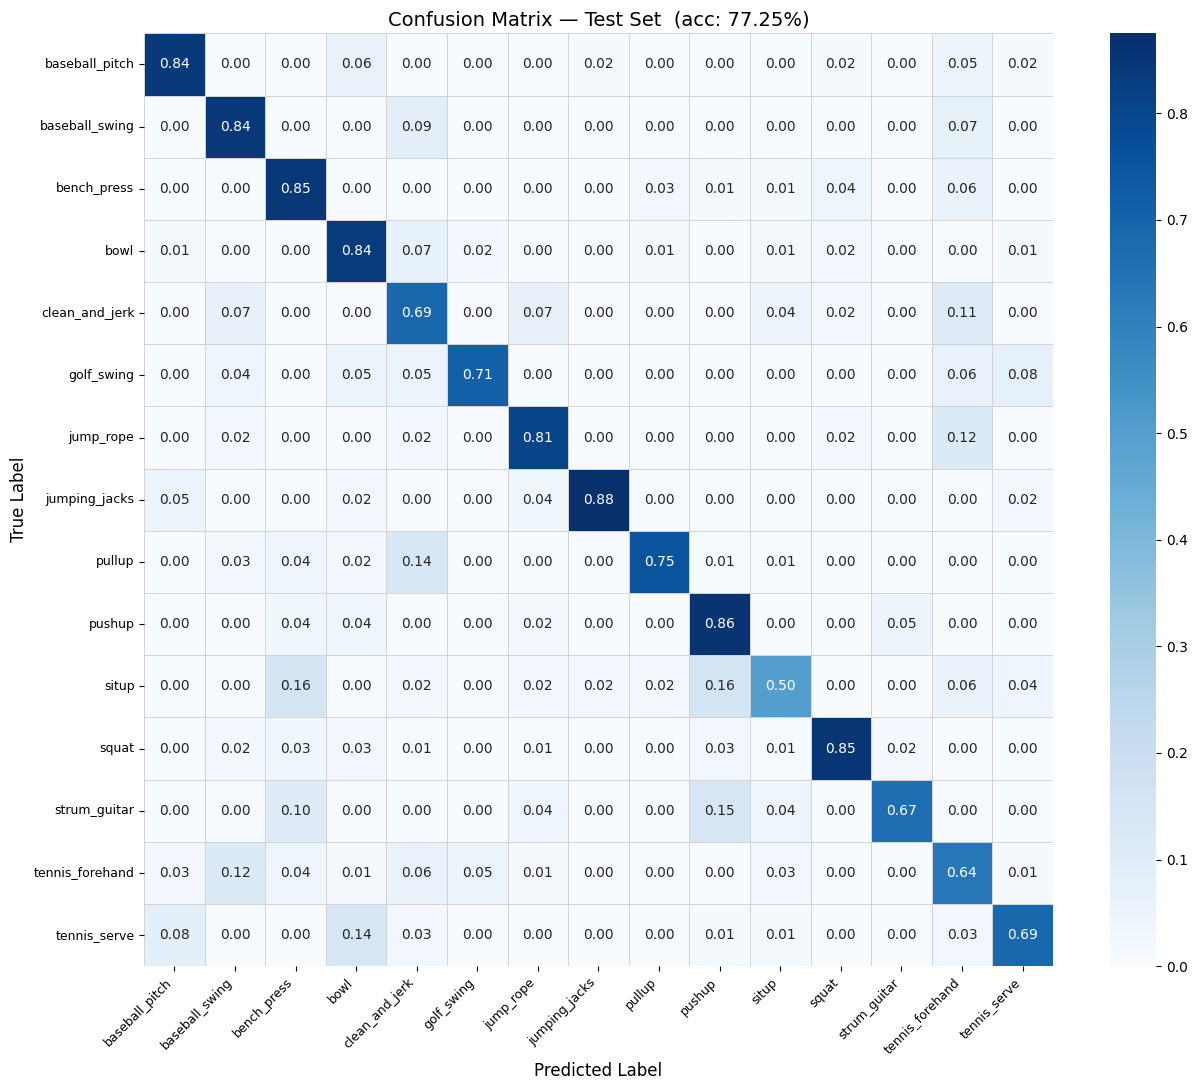


  Confusion matrix saved to confusion_matrix.png and logged to W&B.


best_val_acc,▁▁▂▂▂▃▃▄▄▅▅▅▅▅▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
lr,██████████▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▁▁
train_acc,▁▁▂▃▃▄▄▄▅▅▅▆▅▆▆▆▇▆▆▇▇▇▆▇▇▇▇▇▇▇██████████
train_loss,█▇▆▆▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▄▄▄▅▄▅▅▅▅▅▅▆▇▆▇▇▆▇▆▆▆▆▇▇█████████▇▇
val_loss,█▆▅▆▆▅▄▄▄▄▄▅▄▄▃▃▃▃▂▂▂▁▂▃▂▂▃▃▃▂▁▁▁▁▁▁▂▂▂▂
best_val_acc,82.93651
epoch,59
lr,0.0008
test_accuracy,77.24719


In [24]:
# ─── Model ────────────────────────────────────────────────────────────────────

class STGCNBlock(nn.Module):

    def __init__(self, in_ch, out_ch, A, stride=1, residual=True, dropout=0.0,
                 adaptive=True):
        """
        One ST-GCN block: spatial graph conv -> temporal conv -> residual add.

        Args:
            in_ch    : input channels
            out_ch   : output channels
            A        : raw (unnormalised) adjacency matrix, shape (V, V)
            stride   : temporal stride (1 = no downsampling, 2 = halve T)
            residual : whether to use a residual connection
            dropout  : dropout probability after temporal conv
            adaptive : if True, use learnable adjacency A + B + C (Shi et al.
                       CVPR 2019). If False, use the fixed normalised A only
                       (original ST-GCN baseline behaviour).
        """
        super().__init__()

        self.adaptive = adaptive
        V = A.shape[0]

        # Fixed component: A
        # Normalise once and freeze. Registered as a buffer so it moves to the
        # correct device automatically but is never updated by the optimiser.
        A_norm = normalize_adjacency(A)
        self.register_buffer('A', torch.tensor(A_norm, dtype=torch.float32))

        # Learnable components: B and C (only when adaptive=True)
        if self.adaptive:
            # B: global learnable correction matrix, shape (V, V).
            # Initialised to zero so training starts from pure fixed adjacency
            # and learns deviations only where the data justifies them.
            # Shared across all samples — learns dataset-level joint correlations
            # that the physical skeleton A misses (e.g. bilateral wrist coupling).
            self.B = nn.Parameter(torch.zeros(V, V))

            # θ and φ: two 1×1 conv branches that compress each joint's
            # C-dimensional feature vector to C//4 dimensions.
            # Their dot product produces C — the sample-adaptive attention map.
            # C//4 keeps the cost low; max(1,...) guards against tiny in_ch.
            C_reduced = max(in_ch // 4, 1)
            self.theta = nn.Conv2d(in_ch, C_reduced, kernel_size=1)
            self.phi   = nn.Conv2d(in_ch, C_reduced, kernel_size=1)

        # Spatial graph convolution
        # 1×1 conv mixes channels after neighbourhood aggregation.
        self.gcn_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        self.bn_gcn   = nn.BatchNorm2d(out_ch)

        # Temporal convolution
        # 9-frame kernel captures motion context; stride controls T downsampling.
        self.tcn_conv = nn.Conv2d(
            out_ch, out_ch,
            kernel_size=(9, 1), padding=(4, 0), stride=(stride, 1),
        )
        self.bn_tcn  = nn.BatchNorm2d(out_ch)
        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        # Residual connection
        if not residual:
            self.residual = lambda x: 0
        elif in_ch == out_ch and stride == 1:
            self.residual = nn.Identity()
        else:
            # Project residual to match output channels and temporal resolution.
            self.residual = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=(stride, 1)),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        # x: (N, C, T, V)
        res = self.residual(x)

        if self.adaptive:
            # Build sample-adaptive adjacency Â = A + B + C

            # θ and φ each project x from C to C//4 channels, then average over
            # the time dimension to get one embedding vector per joint per sample.
            # Shape after mean: (N, C//4, V)
            th = self.theta(x).mean(dim=2)
            ph = self.phi(x).mean(dim=2)

            # C: outer product of joint embeddings -> (N, V, V).
            # Entry C[n, i, j] is the dot-product similarity between joint i's
            # and joint j's embeddings for sample n. Softmax normalises each row
            # into a probability distribution over "which joints to attend to".
            # This matrix is recomputed fresh for every input sample.
            C = torch.softmax(
                torch.einsum('nci,ncj->nij', th, ph),
                dim=-1,
            )

            # Combine all three adjacency components.
            # A captures physical bones (frozen), B captures learned dataset-level
            # correlations (shared), C captures per-sample joint co-activation.
            # A is (V, V); B is (V, V); C is (N, V, V).
            # Broadcasting: A and B expand to (N, V, V) automatically.
            A_hat = self.A + self.B + C   # (N, V, V)
            A_hat = A_hat / (A_hat.sum(dim=-1, keepdim=True) + 1e-6)

            # Spatial aggregation with sample-specific adjacency.
            # The einsum kernel gains the batch dimension n compared to the fixed
            # case below: 'nctv,nvw->nctw' instead of 'nctv,vw->nctw'.
            x = torch.einsum('nctv,nvw->nctw', x, A_hat)

        else:
            # Fixed adjacency (baseline behaviour)
            # Same normalised A for every sample; no learnable correction.
            x = torch.einsum('nctv,vw->nctw', x, self.A)

        # Spatial conv -> BN -> ReLU
        x = self.relu(self.bn_gcn(self.gcn_conv(x)))

        # Temporal conv -> BN -> Dropout
        x = self.bn_tcn(self.tcn_conv(x))
        x = self.dropout(x)

        # Residual add -> ReLU
        return self.relu(x + res)


class STGCN_Light(nn.Module):
    """
    6-block lightweight ST-GCN.
    Channels: 2,32,32,64,64,128,128
    Temporal stride-2 at blocks 3 and 5  (T: 100->50->25)
    Head: GlobalAvgPool -> BN -> Dropout -> FC(num_class)

    Args:
        adaptive : propagated to every STGCNBlock. Set True to enable the
                   learnable A + B + C adjacency (Improvement 2). Set False
                   to revert to the fixed normalised adjacency (baseline).
    """

    def __init__(self, num_class=15, in_channels=2, A=None, dropout=0.0,
                 adaptive=True):
        super().__init__()
        if A is None:
            A = get_penn_action_adjacency()

        self.blocks = nn.ModuleList([
            STGCNBlock(in_channels, 32,  A, stride=1, residual=False,
                       dropout=dropout, adaptive=adaptive),
            STGCNBlock(32,          32,  A, stride=1,
                       dropout=dropout, adaptive=adaptive),
            STGCNBlock(32,          64,  A, stride=2,
                       dropout=dropout, adaptive=adaptive),
            STGCNBlock(64,          64,  A, stride=1,
                       dropout=dropout, adaptive=adaptive),
            STGCNBlock(64,          128, A, stride=2,
                       dropout=dropout, adaptive=adaptive),
            STGCNBlock(128,         128, A, stride=1,
                       dropout=dropout, adaptive=adaptive),
        ])

        self.bn_out     = nn.BatchNorm1d(128)
        self.fc_dropout = nn.Dropout(dropout)
        self.fc         = nn.Linear(128, num_class)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 1, 2, 3).contiguous().view(N * M, C, T, V)
        for block in self.blocks:
            x = block(x)
        x = x.mean(dim=[2, 3])             # GlobalAvgPool  (N*M, 128)
        x = x.view(N, M, -1).mean(dim=1)   # average persons  (N, 128)
        x = self.bn_out(x)
        x = self.fc_dropout(x)
        return self.fc(x)


# Training utilities

def run_epoch(model, loader, criterion, device, optimizer=None):
    """One training or evaluation epoch. Returns (avg_loss, accuracy%)."""
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / total, 100.0 * correct / total


def build_model_and_optimiser(cfg, num_classes, device):
    A     = get_penn_action_adjacency()
    model = STGCN_Light(
        num_class=num_classes,
        in_channels=2,
        A=A,
        dropout=cfg["dropout"],
        adaptive=cfg.get("adaptive", True),   # default on; set False for ablation
    ).to(device)
    opt   = torch.optim.Adam(model.parameters(),
                              lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = CosineAnnealingLR(opt, T_max=cfg["num_epochs"], eta_min=1e-6)
    return model, opt, sched


# ─── MODE 1: Hyperparameter sweep ─────────────────────────────────────────────

def sweep_train_fn():
    """Called once per sweep run by wandb.agent."""
    run = wandb.init()
    cfg = {
        "lr":           wandb.config.lr,
        "weight_decay": wandb.config.weight_decay,
        "batch_size":   wandb.config.batch_size,
        "dropout":      wandb.config.dropout,
        "num_epochs":   wandb.config.num_epochs,
        "val_ratio":    wandb.config.val_ratio,
        "seed":         wandb.config.seed,
    }

    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    full_ds  = PennActionDataset(TRAIN_DATA_PATH, TRAIN_LABEL_PATH)
    t_idx, v_idx = stratified_split(full_ds, cfg["val_ratio"], cfg["seed"])
    print(len(v_idx))
    # Sweep uses the non-augmented baseline dataset; pass it as both train and val
    # (make_loaders now requires separate train_dataset and val_dataset arguments)
    train_loader, val_loader = make_loaders(t_idx, v_idx, full_ds, full_ds, cfg["batch_size"])

    model, opt, sched = build_model_and_optimiser(cfg, full_ds.num_classes, device)
    criterion = nn.CrossEntropyLoss()

    wandb.log({"num_params": sum(p.numel() for p in model.parameters() if p.requires_grad)})

    best_val_acc = 0.0
    for epoch in range(1, cfg["num_epochs"] + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, device, opt)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, device)
        sched.step()

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc

        wandb.log({
            "epoch":        epoch,
            "train_loss":   tr_loss, "train_acc": tr_acc,
            "val_loss":     vl_loss, "val_acc":   vl_acc,
            "best_val_acc": best_val_acc,
            "lr":           opt.param_groups[0]["lr"],
        })

    wandb.summary["best_val_acc"] = best_val_acc
    run.finish()


def run_sweep():
    sweep_id = wandb.sweep(SWEEP_CONFIG, project=WANDB_PROJECT, entity=WANDB_ENTITY)
    print(f"Sweep ID: {sweep_id}")
    wandb.agent(sweep_id, function=sweep_train_fn, count=SWEEP_COUNT)


# ─── Early Stopping ───────────────────────────────────────────────────────────

class EarlyStopping:
    """
    Stops training when val_loss fails to improve by at least min_delta
    for a consecutive run of `patience` epochs.

    Monitors val_loss (lower is better) rather than val_acc, because loss
    is a smoother signal — accuracy can plateau while loss still decreases,
    meaning the model is still learning calibration even if top-1 accuracy
    is not changing.

    Args:
        patience  : epochs to wait without improvement before stopping (default 15)
        min_delta : minimum decrease in val_loss to count as improvement (default 0.001)

    Usage:
        stopper = EarlyStopping(patience=15, min_delta=0.001)
        for epoch in ...:
            ...
            if stopper(val_loss):
                break   # stop training
    """

    def __init__(self, patience: int = 15, min_delta: float = 0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0             # consecutive epochs without improvement
        self.best_loss  = float("inf")

    def __call__(self, val_loss: float) -> bool:
        """
        Call once per epoch with the current val_loss.
        Returns True when training should stop.
        """
        if val_loss < self.best_loss - self.min_delta:
            # Genuine improvement — reset counter
            self.best_loss = val_loss
            self.counter   = 0
        else:
            # No meaningful improvement this epoch
            self.counter += 1

        return self.counter >= self.patience


# ─── MODE 2: Train best config, save, evaluate on test set ──────────────────

def run_train_eval():
    """
    Full training run with BEST_CONFIG.
    Saves the best-val-acc checkpoint, then evaluates once on the test set.
    Logs everything to a single W&B run.
    """
    cfg = BEST_CONFIG.copy()

    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n{'='*60}")
    print(f"  TRAIN MODE  —  {cfg['num_epochs']} epochs  |  device: {device}")
    print(f"  Adaptive adjacency: {cfg.get('adaptive', True)}")
    print(f"  Config: {cfg}")
    print(f"{'='*60}\n")

    # ── Data ──────────────────────────────────────────────────────────────────
    # Two dataset instances over the same training .npy files:
    #   train_ds  — training=True  = augmentation active in __getitem__
    #   val_ds    — training=False = clean sequences only (no augmentation)
    # Using a single instance for both would incorrectly augment val samples,
    # creating a train/val distribution mismatch and unreliable val metrics.
    train_ds = PennActionDatasetAug(TRAIN_DATA_PATH, TRAIN_LABEL_PATH, training=False)
    val_ds   = PennActionDatasetAug(TRAIN_DATA_PATH, TRAIN_LABEL_PATH, training=False)
    test_ds  = PennActionDatasetAug(TEST_DATA_PATH,  TEST_LABEL_PATH,  training=False)
    num_classes = train_ds.num_classes

    t_idx, v_idx = stratified_split(train_ds, cfg["val_ratio"], cfg["seed"])
    train_loader, val_loader = make_loaders(t_idx, v_idx, train_ds, val_ds, cfg["batch_size"])
    test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"],
                             shuffle=False, num_workers=2, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    model, opt, sched = build_model_and_optimiser(cfg, num_classes, device)
    criterion = nn.CrossEntropyLoss()
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters: {num_params:,}\n")

    # ── W&B run ───────────────────────────────────────────────────────────────
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name="best-config-full-train",
        config={**cfg, "num_params": num_params, "mode": "train_eval"},
    )

    # ── Training loop ─────────────────────────────────────────────────────────
    best_val_acc  = 0.0
    best_epoch    = 0
    early_stopper = EarlyStopping(
        patience  = cfg["es_patience"],
        min_delta = cfg["es_min_delta"],
    )

    for epoch in range(1, cfg["num_epochs"] + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, device, opt)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, device)
        sched.step()
        current_lr = opt.param_groups[0]["lr"]

        # Save checkpoint whenever val_acc improves
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_epoch   = epoch
            torch.save(model.state_dict(), MODEL_SAVE_PATH)

        wandb.log({
            "epoch":        epoch,
            "train_loss":   tr_loss, "train_acc":    tr_acc,
            "val_loss":     vl_loss, "val_acc":      vl_acc,
            "best_val_acc": best_val_acc,
            "lr":           current_lr,
        })

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}  "
                  f"train {tr_loss:.4f}/{tr_acc:.1f}%  "
                  f"val {vl_loss:.4f}/{vl_acc:.1f}%  "
                  f"(best val {best_val_acc:.1f}% @ ep {best_epoch})  "
                  f"[patience {early_stopper.counter}/{early_stopper.patience}]")

        if early_stopper(vl_loss):
            print(f"\n  Early stopping triggered at epoch {epoch} "
                  f"(no improvement in val_loss for {cfg['es_patience']} epochs)")
            break

    print(f"\n  Training complete. Best val acc: {best_val_acc:.2f}% at epoch {best_epoch}")
    print(f"  Checkpoint saved to: {MODEL_SAVE_PATH}\n")

    # ── Test evaluation ───────────────────────────────────────────────────────
    print("  Loading best checkpoint for test evaluation...")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            preds = model(x.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    test_acc = accuracy_score(all_labels, all_preds) * 100.0
    cm       = confusion_matrix(all_labels, all_preds)

    print(f"\n  ── Test Set Results ──")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3)}")

    wandb.summary["best_val_acc"]  = best_val_acc
    wandb.summary["test_accuracy"] = test_acc

    # ── Confusion matrix plot ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 11))

    # Normalise rows to fractions
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.4, linecolor="lightgrey",
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix — Test Set  (acc: {test_acc:.2f}%)", fontsize=14)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_xlabel("Predicted Label", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()

    cm_path = "confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()

    wandb.log({"confusion_matrix": wandb.Image(cm_path)})
    print(f"\n  Confusion matrix saved to {cm_path} and logged to W&B.")

    run.finish()
    return test_acc, cm


# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":


    # Set MODE = "sweep"  for hyperparameter search
    # Set MODE = "train"  for train best config, save, and evaluate

    MODE = "train"   #
    # Available modes:
    #   "sweep"  : Bayesian hyperparameter search (HT mode)
    #   "train"  : train one model with BEST_CONFIG, evaluate on test set.
    #              Covers ablation conditions (1)-(3) via the `adaptive` flag
    #              and the training=True/False setting in PennActionDatasetAug.
    #   "fusion" : Improvement 3 — train four single-stream models and
    #              evaluate (2:1:2:1) score-level fusion. Ablation row (4).

    if MODE == "sweep":
        print("Starting hyperparameter sweep...")
        run_sweep()

    elif MODE == "train":
        print("Starting full training + test evaluation...")
        test_acc, cm = run_train_eval()

    elif MODE == "fusion":
        print("Starting four-stream fusion training + evaluation...")
        fusion_results = run_four_stream_fusion()

    else:
        raise ValueError(
            f"Unknown MODE '{MODE}'. Choose 'sweep', 'train', or 'fusion'."
        )